# Hotel Booking Demand Analysis
## Explorative Data Analysis
## 2nd Iteration
* **Goal:** Explore booking pattern and cancellation rates

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Safe Data Loading with try/except

file_path = '../data/hotel_bookings.csv'
try:
    df = pd.read_csv(file_path)
    print(f'File loaded successfully')
except FileNotFoundError:
    print(f'File not found - check {file_path}')

File loaded successfully


In [2]:
# Inspection of Dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Shape of Dataset
print(f'Rows:{df.shape[0]} -- Columns:{df.shape[1]}')

Rows:119390 -- Columns:32


In [4]:
# Check for Dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# Check on the statistic metrics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
# Check for missing values
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

**Note on Missing Values:**  
In this second iteration, missing values will be handled earlier to support cleaner analysis and visualizations.

* `children`: Missing values will be imputed using the mode for `City Hotel`, since all missing values occur in this hotel type.
* `agent` and `company`: Missing values will be filled with `0`, assuming no agent or company was involved.
* `country`: Missing values will be filled with `UNK` to represent unknown country information.

In [7]:
# Check Duplicates
df.duplicated().sum()

np.int64(31994)

**Note on Duplicates:** Since the dataset is anonymous, there is no unique indicator to tell if identical rows are actual technical duplicates, group bookings, or company bookings. In the first iteration, the EDA included all duplicates. For this second iteration, I will split the dataset into two versions—one with duplicates and one without. This allows me to analyze how the relationships between variables and the overall numbers differ between the two datasets.

## Filling Missing Values

In [8]:
# Create a copy for EDA cleaning
df_eda = df.copy()

In [9]:
# Filling missing values on agent and company with 0 for no agent and no company
df_eda['agent'] = df_eda['agent'].fillna(0)
df_eda['company'] = df_eda['company'].fillna(0)

# Check if it works
print(df_eda[['agent', 'company']].isna().sum())

agent      0
company    0
dtype: int64


In [10]:
# Filling missing values country with UNK for unknown
df_eda['country'] = df_eda['country'].fillna('UNK')

# Check the result
print(df_eda['country'].isna().sum())

0


In [11]:
# Check the hotel with the 4 missing values
print(df_eda[df_eda['children'].isna()])

            hotel  is_canceled  lead_time  arrival_date_year  \
40600  City Hotel            1          2               2015   
40667  City Hotel            1          1               2015   
40679  City Hotel            1          1               2015   
41160  City Hotel            1          8               2015   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
40600             August                        32                          3   
40667             August                        32                          5   
40679             August                        32                          5   
41160             August                        33                         13   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
40600                        1                     0       2  ...   
40667                        0                     2       2  ...   
40679                        0                     2       3  ... 

In [12]:
# Creating variable for input
city_child = df_eda[df_eda['hotel'] == 'City Hotel']['children'].mode()[0]

# Filling the missing values
df_eda['children'] = df_eda['children'].fillna(city_child)

In [13]:
# Check again for missing values
df_eda.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

**Note on Missing Values:**  
After applying the imputation strategy, there are no remaining missing values in the dataset. Next, the dataset will be split into two versions: one including duplicates and one with duplicates removed.

In [14]:
# Creating two different datasets - one with duplicates and one without duplicates
df_eda_with_dup = df_eda.copy()
df_eda_no_dup = df_eda.drop_duplicates().copy()

# Check the shape of both datasets
print(f'Dataset with duplicates: {df_eda_with_dup.shape}')
print(f'Dataset without duplicates: {df_eda_no_dup.shape}')

Dataset with duplicates: (119390, 32)
Dataset without duplicates: (87396, 32)


## Visualisations after filling missing values and splitting dataset

In [15]:
# Checking the cancellation by dataset
print('Cancellation Rate with Duplicates:',round(df_eda_with_dup['is_canceled'].mean()*100,2),'%')
print('Cancellation Rate without Duplicates:', round(df_eda_no_dup['is_canceled'].mean()*100,2),'%')

Cancellation Rate with Duplicates: 37.04 %
Cancellation Rate without Duplicates: 27.49 %


**Note on Duplicate Impact:**
A comparison of both datasets reveals a significant insight: while the full dataset (including duplicates) contains 119,390 entries, the cleaned dataset (excluding duplicates) comprises 87,396 entries. Interestingly, removing these duplicates leads to a drop of 10% in the overall cancellation rate. 

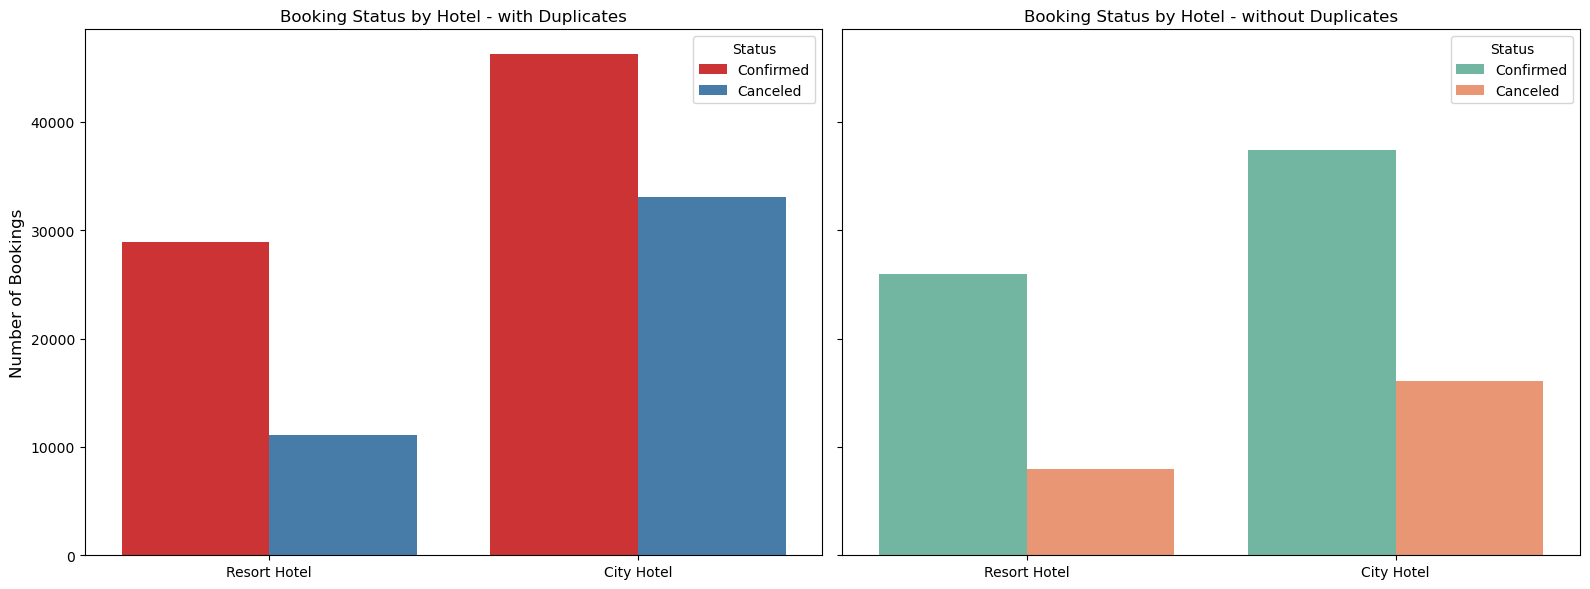

In [16]:
# Visualize the comparison by hotel
fig, axes = plt.subplots(1,2, figsize=(16,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.countplot(data=df_eda_with_dup, x='hotel', hue='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Booking Status by Hotel - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Confirmed', 'Canceled'])

# Second Plot - Dataset without Duplicates
sns.countplot(data=df_eda_no_dup, x='hotel', hue='is_canceled', palette='Set2', ax=axes[1])
axes[1].set_title('Booking Status by Hotel - without Duplicates', fontsize=12)
axes[1].set_xlabel('')
axes[1].legend(title='Status', labels=['Confirmed', 'Canceled'])

plt.tight_layout()
plt.show()

### Analysis of Booking Status by Hotel Type (Dataset Comparison)

* **Consistent Trends:** Both datasets reveal a similar baseline pattern: the City Hotel shows substantially higher cancellation volumes than the Resort Hotel.
* **With Duplicates (Full Dataset):** In the full dataset, City Hotel cancellations exceed 30,000 compared to roughly 50,000 confirmed bookings. This makes cancellations appear more dominant in the operational picture.
* **Without Duplicates (Cleaned Dataset):** After removing 31,994 duplicate entries, City Hotel cancellations drop to around 20,000, while confirmed bookings remain close to 40,000. The City Hotel still has a higher cancellation burden than the Resort Hotel, but the difference appears less inflated than in the full dataset.
* **Key Takeaway:** Removing duplicates changes the overall cancellation rate from 37% to 27%, showing that duplicate records have a meaningful impact on the cancellation analysis.

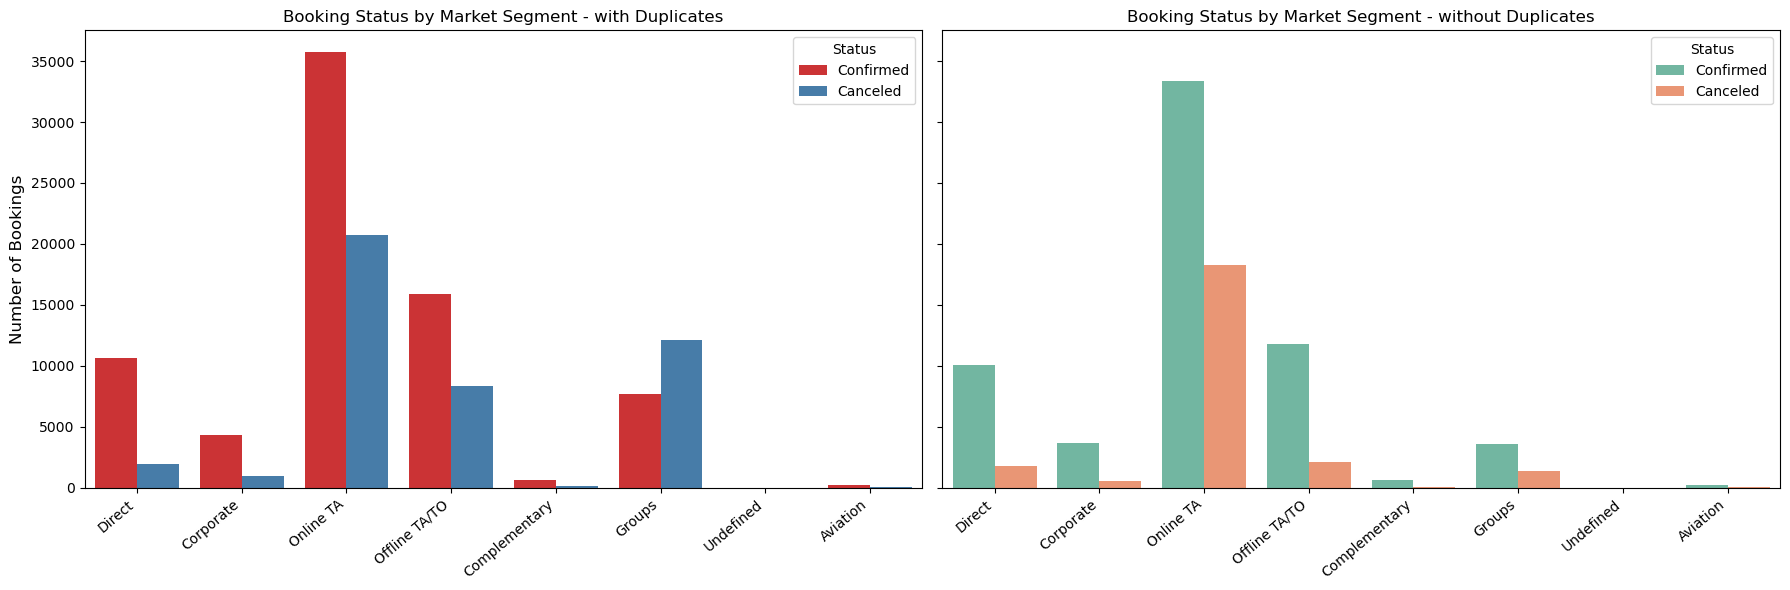

In [17]:
# Visualize the Booking Status by Market Segment
fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.countplot(data=df_eda_with_dup, x='market_segment', hue='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Booking Status by Market Segment - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Confirmed', 'Canceled'])
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# Second Plot - Dataset without Duplicates
sns.countplot(data=df_eda_no_dup, x='market_segment', hue='is_canceled', palette='Set2', ax=axes[1])
axes[1].set_title('Booking Status by Market Segment - without Duplicates', fontsize=12)
axes[1].legend(title='Status', labels=['Confirmed', 'Canceled'])
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### Analysis of Booking Status by Market Segment (Dataset Comparison)

* **The "Groups" Inversion Effect:** The charts clearly demonstrate that a significant portion of the duplicate entries stemmed from group bookings. In the dataset *with* duplicates, group cancellations outnumber confirmed bookings (nearly 15,000 cancellations vs. roughly 10,000 confirmations). However, in the deduplicated dataset, this pattern completely inverts: total group bookings drop drastically, and confirmed bookings actually outnumber cancellations (nearly 5,000 confirmations vs. roughly 2,500 cancellations). This shift heavily indicates that the duplicates were driven by large-scale, bulk group bookings that were canceled simultaneously.
* **Impact on Offline TA/TO:** A similar, substantial distortion is visible in the *Offline TA/TO* (Offline Travel Agents / Tour Operators) segment. In the dataset with duplicates, cancellations hover around 8,000. Once the duplicates are removed, this number plunges to approximately 2,500. 
* **Strategic Takeaway:** This comparison proves that keeping duplicates would severely trick any machine learning model or business report into thinking that Groups and Offline Agencies are highly unstable and prone to cancellation, when in reality, a few massive bulk events skewed the entire baseline.

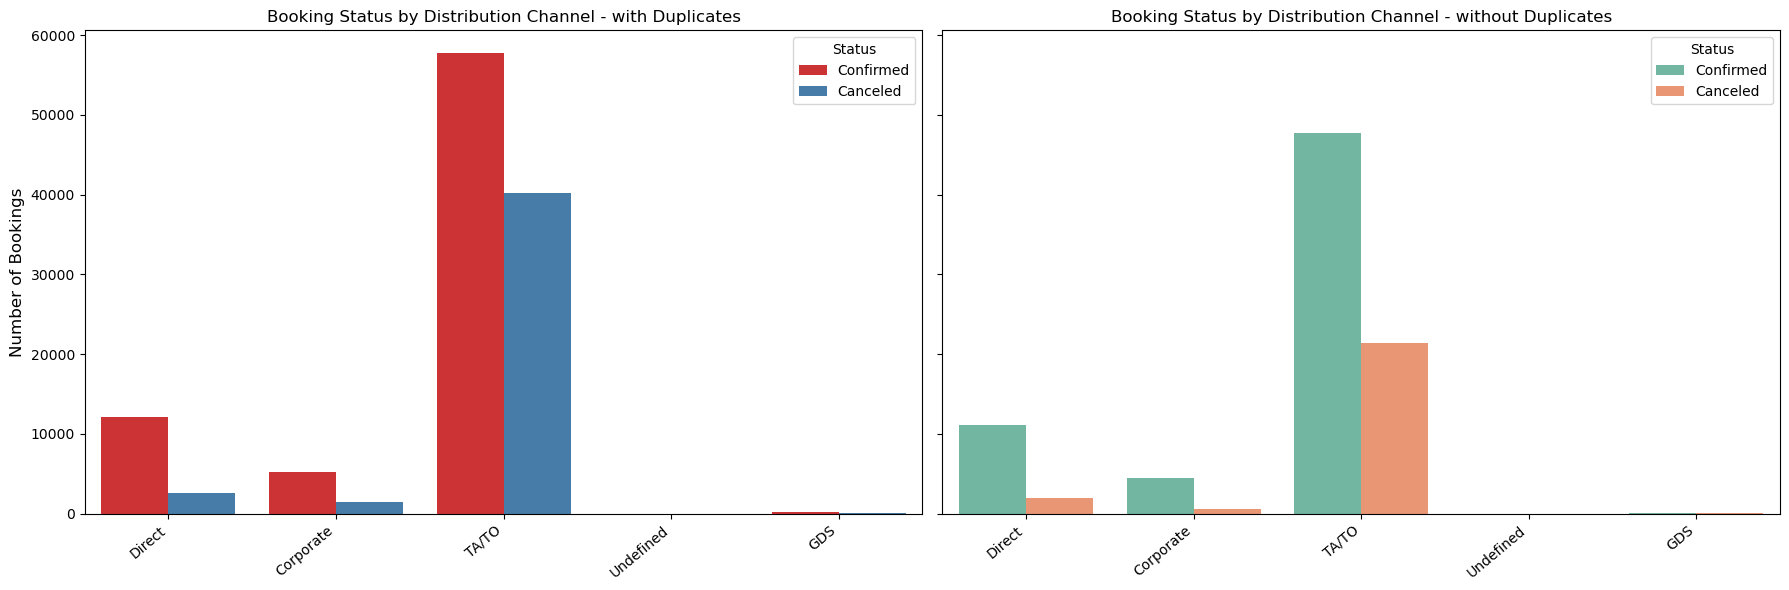

In [18]:
# Checking the cancellation by distribution channel
fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.countplot(data=df_eda_with_dup, x='distribution_channel', hue='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Booking Status by Distribution Channel - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Confirmed', 'Canceled'])
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# Second Plot - Dataset without Duplicates
sns.countplot(data=df_eda_no_dup, x='distribution_channel', hue='is_canceled', palette='Set2', ax=axes[1])
axes[1].set_title('Booking Status by Distribution Channel - without Duplicates', fontsize=12)
axes[1].legend(title='Status', labels=['Confirmed', 'Canceled'])
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### Analysis of Booking Status by Distribution Channel (Dataset Comparison)

* **Dominance of TA/TO:** In both datasets, the "TA/TO" (Travel Agents / Tour Operators) channel accounts for the overwhelming majority of all bookings. Consequently, the visual comparison confirms that the bulk of the 31,994 duplicate entries are concentrated within this single category, further supporting the theory of large-scale agency bulk bookings.
* **Strategic Financial Implication:** Because TA/TO bookings typically incur high commission fees and exhibit the highest cancellation volatility, this massive concentration represents a financial risk. 
* **Actionable Recommendation:** The hotel management should consider a targeted pricing and marketing strategy (e.g., direct-booking discounts, loyalty perks) to boost the "Direct" booking channel. Shifting share away from TA/TO toward direct bookings would drastically reduce commission costs and improve overall booking stability.

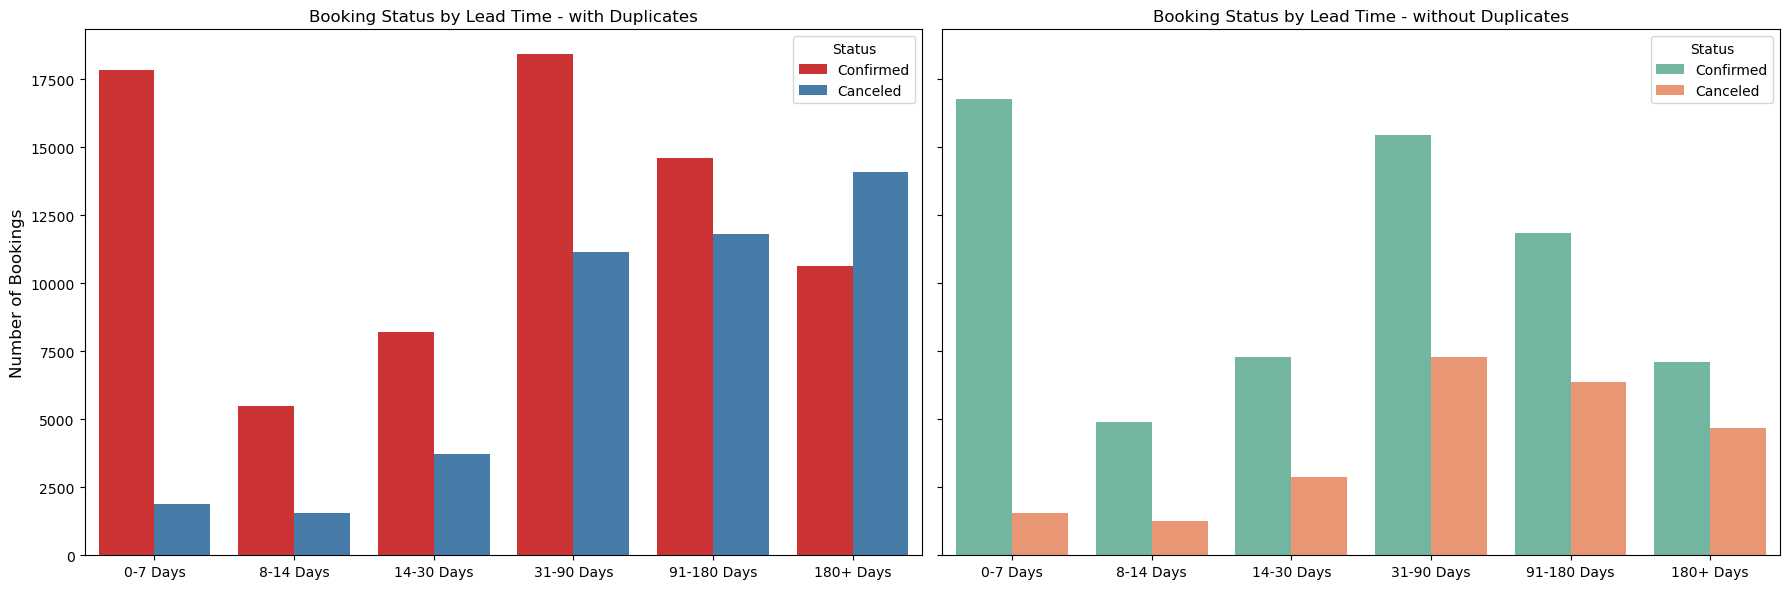

In [19]:
# Splitting Lead Time into bins
lead_time_bins = [-1, 7, 14, 30, 90, 180, float('inf')]
lead_time_labels = ['0-7 Days', '8-14 Days', '14-30 Days', '31-90 Days', '91-180 Days', '180+ Days']

df_eda_with_dup['lead_time_group'] = pd.cut(df_eda_with_dup['lead_time'], bins=lead_time_bins, labels=lead_time_labels)
df_eda_no_dup['lead_time_group'] = pd.cut(df_eda_no_dup['lead_time'], bins=lead_time_bins, labels=lead_time_labels)

fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.countplot(data=df_eda_with_dup, x='lead_time_group', hue='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Booking Status by Lead Time - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Confirmed', 'Canceled'])

# Second Plot - Dataset without Duplicates
sns.countplot(data=df_eda_no_dup, x='lead_time_group', hue='is_canceled', palette='Set2', ax=axes[1])
axes[1].set_title('Booking Status by Lead Time - without Duplicates', fontsize=12)
axes[1].legend(title='Status', labels=['Confirmed', 'Canceled'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### Analysis of Booking Status by Lead Time (Dataset Comparison)

* **General Volume Trends:** In both datasets, the highest volume of overall bookings occurs within the ultra-short-term window of 0–7 days prior to arrival, closely followed by the mid-term 31–90 days window.
* **The "Lead Time Distortion" in Long-Term Bookings:** The visual comparison reveals a striking divergence in long-term booking behavior. In the dataset *with* duplicates, cancellations appear to escalate as the lead time grows, peaking heavily in the 91–180 days and 180+ days categories. 
* **The Realistic Pattern (Deduplicated):** Once duplicates are removed, this trend completely reverses. In the clean dataset, cancellation demand peaks significantly in the 31–90 days window and steadily decreases for the 91–180 days and 180+ days brackets. 
* **Business Insight:** This confirms that long-term, far-in-advance bookings are heavily tied to the duplicate bulk bookings we discovered earlier (likely tour operators or event blocks). Relying on the raw dataset would heavily mislead management into believing that long-term individual guests are highly unreliable, whereas the clean data proves that short-to-mid-term bookings actually carry the highest active cancellation risk.

In [20]:
# Creating 'total_length_of_stay' and 'booking_value' to check the missed booking value of 10%
# Create the total length for the dataset without duplicates
df_eda_no_dup['total_length_of_stay'] = df_eda_no_dup['stays_in_weekend_nights'] + df_eda_no_dup['stays_in_week_nights']

# Create the total length for the dataset with duplicates
df_eda_with_dup['total_length_of_stay'] = df_eda_with_dup['stays_in_weekend_nights'] + df_eda_with_dup['stays_in_week_nights']

# Create the booking value colum for the dataset without duplicates
df_eda_no_dup['booking_value'] = df_eda_no_dup['total_length_of_stay'] * df_eda_no_dup['adr']

# Create the booking value colum for the dataset with duplicates
df_eda_with_dup['booking_value'] = df_eda_with_dup['total_length_of_stay'] * df_eda_with_dup['adr']

In [21]:
# Calculate the booking value for both datasets
booking_val_with_dup = df_eda_with_dup[df_eda_with_dup['is_canceled'] == 0]['booking_value'].sum()
booking_val_no_dup = df_eda_no_dup[df_eda_no_dup['is_canceled'] == 0]['booking_value'].sum()
difference = round(booking_val_with_dup - booking_val_no_dup, 2)

print('---Confirmed Booking Value Overview--')
print(f'Booking Value WTIH Duplicates: {booking_val_with_dup:.2f} $')
print(f'Booking Value NO Duplicates: {booking_val_no_dup:.2f} $')
print(f'Difference: {difference} $')

---Confirmed Booking Value Overview--
Booking Value WTIH Duplicates: 25996260.41 $
Booking Value NO Duplicates: 22976896.33 $
Difference: 3019364.08 $


### Analysis of the Confirmed Revenue Value (Dataset Comparison)

* **The Analytical Constraint:** Since the dataset lacks a unique transaction identifier (such as a confirmation or invoice ID), it is impossible to definitively prove the root cause of these identical records.
* **Strategic Value of the Confirmed Revenue Calculation:** Shifting the focus to confirmed bookings (`is_canceled == 0`) provides a critical sanity check for the hotel's actual revenue pipeline. Quantifying the financial difference highlights an important operational consideration:
  1. *Under the Duplicate Hypothesis:* If these identical records are technical system anomalies, the raw data creates a significant revenue mirage—misleading management into projecting **$25,996,260.41** in realized cash flows when the true baseline is **$22,976,896.33**. This introduces an artificial distortion of **$3,019,364.08**.
  2. *Under the Bulk Booking Hypothesis:* If these represent real, identical group allocations that successfully checked in, keeping them intact reflects the true historical volume but introduces a heavy structural bias toward specific repeat patterns.

In [22]:
# Calculate the cancellation booking value for both datasets
cxl_val_with_dup = df_eda_with_dup[df_eda_with_dup['is_canceled'] == 1]['booking_value'].sum()
cxl_val_no_dup = df_eda_no_dup[df_eda_no_dup['is_canceled'] == 1]['booking_value'].sum()
cxl_difference = round(cxl_val_with_dup - cxl_val_no_dup, 2)

print('---Cancellation Value Overview--')
print(f'Cancellation Volumn Value WTIH Duplicates: {cxl_val_with_dup:.2f} $')
print(f'Cancellation Volumn Value NO Duplicates: {cxl_val_no_dup:.2f} $')
print(f'Difference: {cxl_difference} $')

---Cancellation Value Overview--
Cancellation Volumn Value WTIH Duplicates: 16727237.12 $
Cancellation Volumn Value NO Duplicates: 11484042.98 $
Difference: 5243194.14 $


### Analysis of the Cancellation Revenue Value (Dataset Comparison)

* **The Analytical Constraint:** Since the dataset lacks a unique transaction identifier (such as a confirmation or invoice ID), it is impossible to definitively prove whether the 31,994 identical rows represent technical system duplicates or a real, large-scale bulk group booking that was canceled simultaneously. 
* **Strategic Value of the Cancellation Calculation:** Despite this limitation, quantifying the financial difference remains a crucial consideration for business strategy:
  1. *Under the Duplicate Hypothesis:* The raw reporting presents a financial mirage, misleading management with artificial, non-realized losses.
  2. *Under the Group Booking Hypothesis:* Treating a single bulk cancellation decision as 31,994 independent events introduces severe structural bias. A machine learning model trained on this raw data would drastically overestimate the risk of the *Groups* or *Offline TA/TO* segments.

In [23]:
# Creating Arrival Date in column from 'arrival_date_year', 'arrival_date_month' and 'arrival_date_day_of_month'
def create_arrival_date (dataframe):
    new_arrival_date_format = (
        dataframe['arrival_date_year'].astype(str) + '-' +
        dataframe['arrival_date_month'] + '-' +
        dataframe['arrival_date_day_of_month'].astype(str) 
    )
    return pd.to_datetime(new_arrival_date_format, format='%Y-%B-%d')

In [24]:
# Create the new column 'arrival_date' for both datasets
df_eda_with_dup['arrival_date'] = create_arrival_date(df_eda_with_dup)
df_eda_no_dup['arrival_date'] = create_arrival_date(df_eda_no_dup)

In [25]:
# Checking the monthly revenue for confirmed bookings by dataset
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_eda_with_dup['arrival_date_month'] = pd.Categorical(df_eda_with_dup['arrival_date_month'], categories=months_order, ordered=True)
df_eda_no_dup['arrival_date_month'] = pd.Categorical(df_eda_no_dup['arrival_date_month'], categories=months_order, ordered=True)

monthly_rev_with_dup = df_eda_with_dup[df_eda_with_dup['is_canceled'] == 0].groupby('arrival_date_month', observed=True)['booking_value'].sum().reset_index()
monthly_rev_no_dup = df_eda_no_dup[df_eda_no_dup['is_canceled'] == 0].groupby('arrival_date_month', observed=True)['booking_value'].sum().reset_index()

print(monthly_rev_with_dup)
print(monthly_rev_no_dup)

   arrival_date_month  booking_value
0             January      776676.84
1            February     1147541.48
2               March     1652098.59
3               April     2099857.48
4                 May     2395213.64
5                June     2583290.92
6                July     4100397.07
7              August     4917159.06
8           September     2344263.36
9             October     1856816.72
10           November     1035552.96
11           December     1087392.29
   arrival_date_month  booking_value
0             January      705407.21
1            February     1025077.03
2               March     1416047.15
3               April     1805375.46
4                 May     2060619.53
5                June     2296399.43
6                July     3799350.53
7              August     4608288.90
8           September     1970554.65
9             October     1476094.71
10           November      893645.61
11           December      920036.12


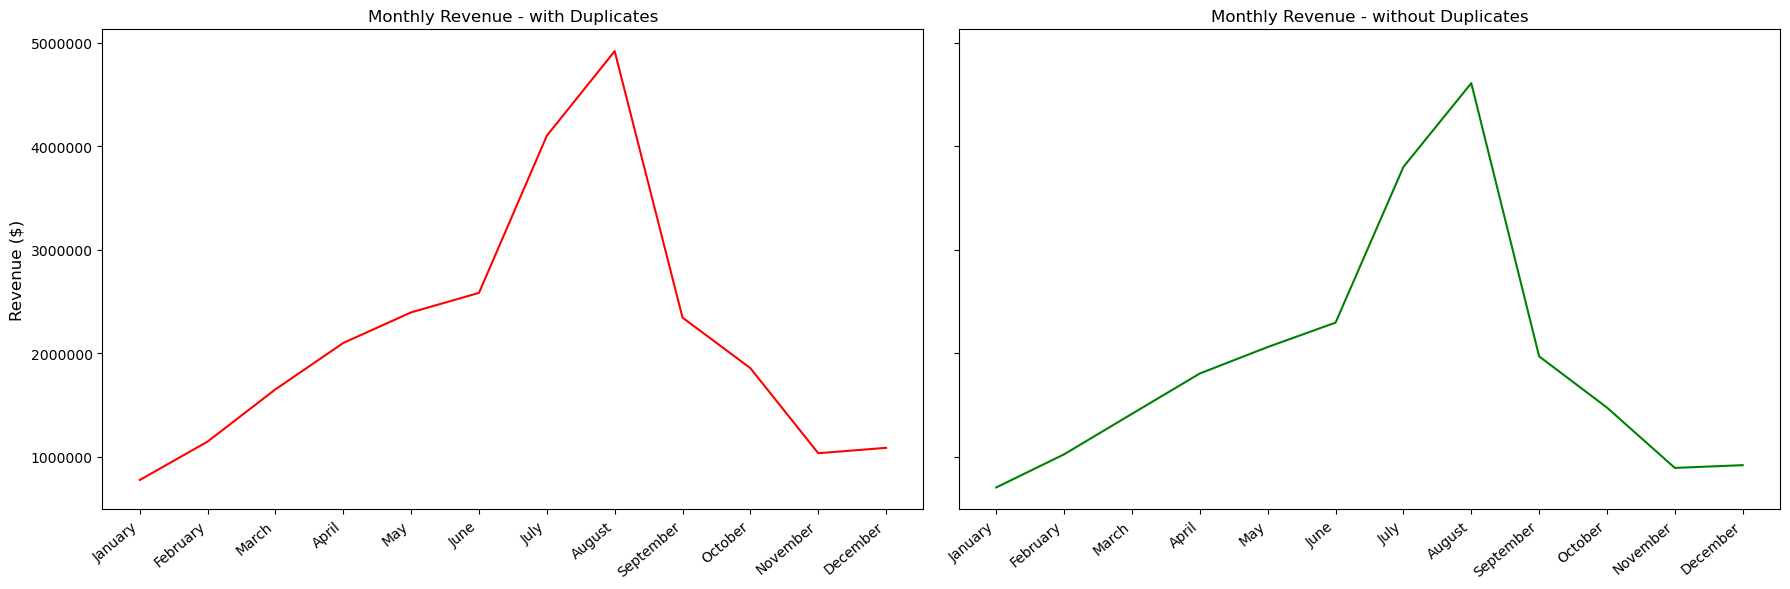

In [26]:
# Visualize the monthly revenue
fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.lineplot(data=monthly_rev_with_dup, x='arrival_date_month', y='booking_value', ax=axes[0], color='red')
axes[0].set_title('Monthly Revenue - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# Second Plot - Dataset without Duplicates
sns.lineplot(data=monthly_rev_no_dup, x='arrival_date_month', y='booking_value', ax=axes[1], color='green')
axes[1].set_title('Monthly Revenue - without Duplicates', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

### Monthly Revenue & Seasonality Analysis (Dataset Comparison)

* **Pronounced Seasonality:** The analysis reveals a distinct demand peak during the summer months, with a steady upward trend beginning in April and peaking mid-year.
* **Winter Low Season:** Conversely, a significant drop in revenue is observed during the winter period, extending from October through February.
* **Strategic Recommendation (Dynamic Pricing):** To maximize profitability and optimize occupancy, the hotel management should implement a dynamic pricing strategy:
  * **High-Demand Periods:** Implement premium pricing during the summer peak to capture maximum margin.
  * **Low-Demand Periods:** Introduce targeted promotional offers, packages, or competitive off-season rates to stimulate demand and cover fixed operating costs during the winter slump.

[Text(0, 0, 'Direct'),
 Text(1, 0, 'Corporate'),
 Text(2, 0, 'Online TA'),
 Text(3, 0, 'Offline TA/TO'),
 Text(4, 0, 'Complementary'),
 Text(5, 0, 'Groups'),
 Text(6, 0, 'Undefined'),
 Text(7, 0, 'Aviation')]

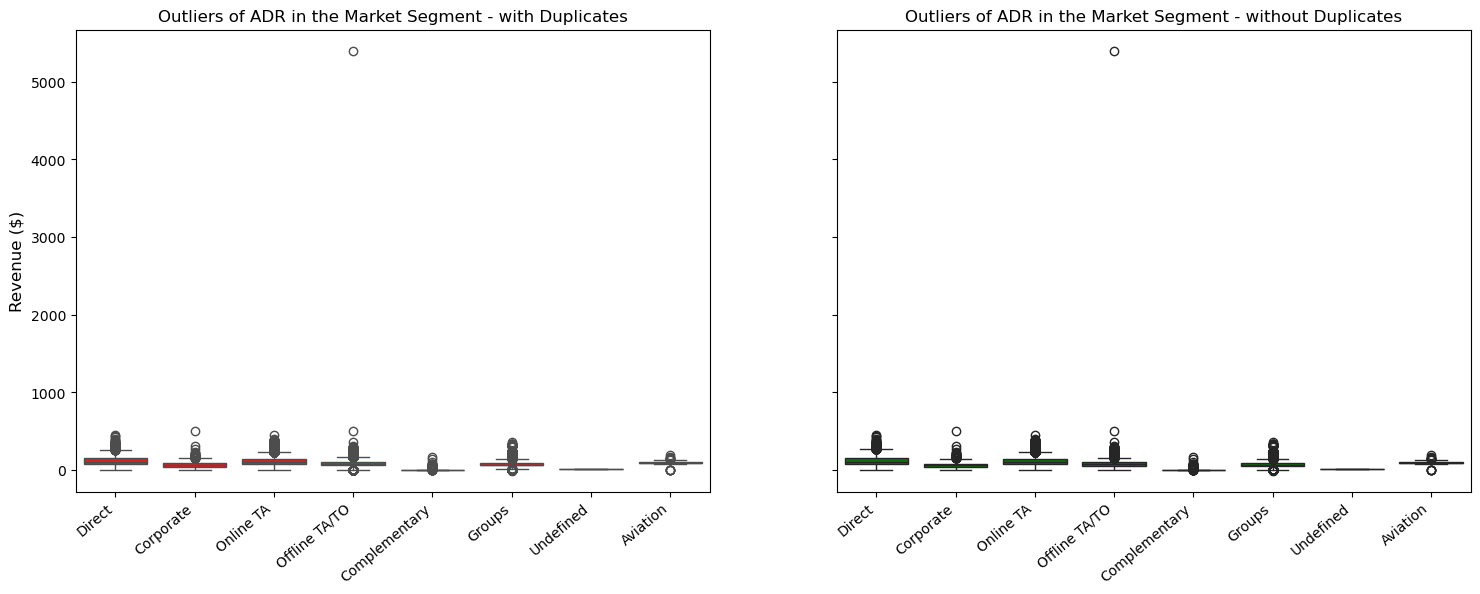

In [27]:
# Checking on Outliers in the Average Daily Rate
fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.boxplot(data=df_eda_with_dup, x='market_segment', y='adr', ax=axes[0], color='red')
axes[0].set_title('Outliers of ADR in the Market Segment - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# Second Plot - Dataset without Duplicates
sns.boxplot(data=df_eda_no_dup, x='market_segment', y='adr', ax=axes[1], color='green')
axes[1].set_title('Outliers of ADR in the Market Segment - without Duplicates', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

### ADR Outlier Analysis (Dataset Comparison)
* **Identification of Extreme Outlier:** The boxplot analysis highlights a severe statistical anomaly within the `Offline TA/TO` market segment, featuring an Average Daily Rate (ADR) exceeding **$5,000**.
* **Business Impact & Data Handling Strategy:** * Because this specific booking was ultimately canceled (`is_canceled == 1`), it introduces zero distortion into actual realized revenue metrics.
  * To preserve the original record volume and avoid unnecessary data manipulation, this row is intentionally retained in both datasets. It serves as an excellent example of tracking operational data noise without affecting final financial KPIs.

[Text(0, 0, 'Direct'),
 Text(1, 0, 'Corporate'),
 Text(2, 0, 'Online TA'),
 Text(3, 0, 'Offline TA/TO'),
 Text(4, 0, 'Complementary'),
 Text(5, 0, 'Groups'),
 Text(6, 0, 'Undefined'),
 Text(7, 0, 'Aviation')]

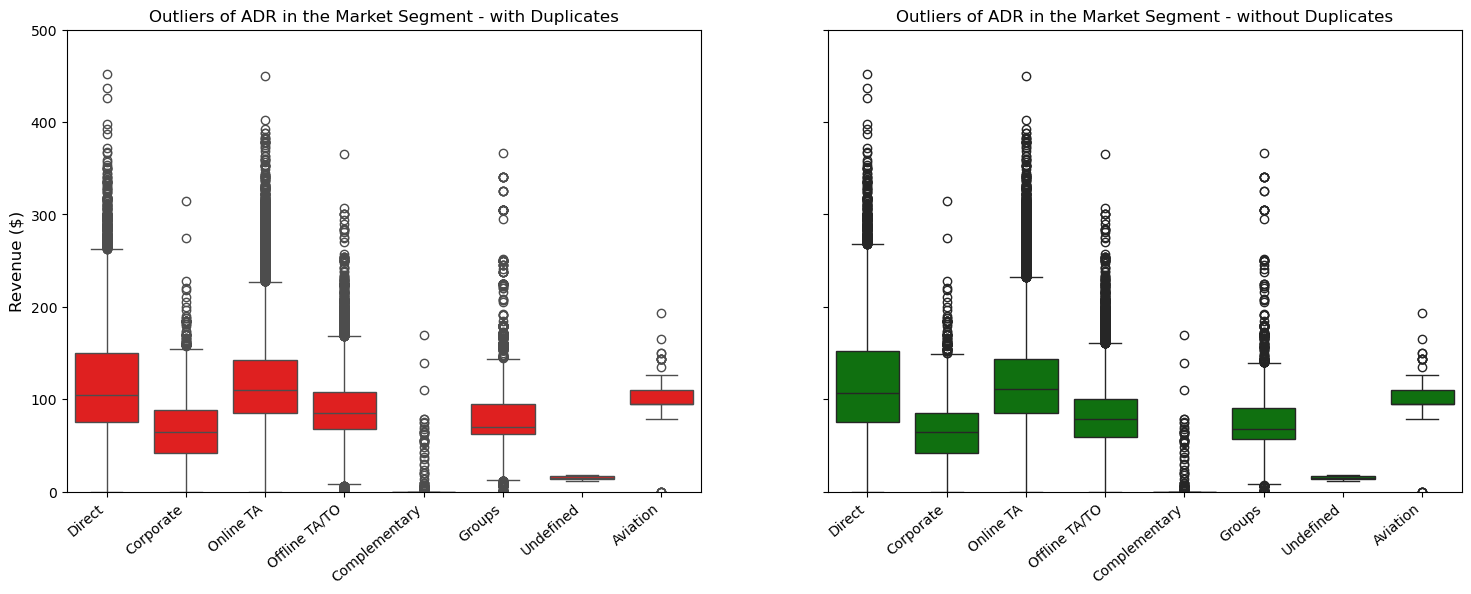

In [28]:
# Check the outliers with limit of 500$ on the y label

# Checking on Outliers in the Average Daily Rate
fig, axes = plt.subplots(1,2, figsize=(18,6), sharey=True)

# First Plot - Dataset with Duplicates
sns.boxplot(data=df_eda_with_dup, x='market_segment', y='adr', ax=axes[0], color='red')
axes[0].set_title('Outliers of ADR in the Market Segment - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')
axes[0].set_ylim(0, 500)

# Second Plot - Dataset without Duplicates
sns.boxplot(data=df_eda_no_dup, x='market_segment', y='adr', ax=axes[1], color='green')
axes[1].set_title('Outliers of ADR in the Market Segment - without Duplicates', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

### Comparative ADR Distribution Y-Axis Capped at $500 (Dataset Comparison)

* **Scale Optimization for Granular Insights:** To counteract the visual compression caused by the extreme $5,400 outlier, the vertical axis scale was restricted to a range of **$0 to $500** (`set_ylim(0, 500)`). This allows a precise comparative evaluation of the core data distribution across all market segments.
* **Core Distribution Stability:** The comparison reveals that the overall distribution structural profile (IQR, medians, and upper bounds) remains highly consistent between the two datasets, confirming that dropping the 32,000 duplicate rows does not structurally shift the underlying pricing baselines of individual segments.
* **Segment-Specific Observations:** * The `Aviation` and `Direct` booking segments maintain a higher median ADR compared to traditional groups.
  * The `Groups` segment exhibits a significantly compressed interquartile range (IQR) with lower pricing variance, reflecting standardized group contract rates.
  * Persistent outliers above the $300 threshold across multiple segments represent valid luxury bookings or peak-season pricing variants rather than data entry anomalies.

In [29]:
# Check for mean booking value by marked segment
avg_adr_with_dup = df_eda_with_dup[df_eda_with_dup['is_canceled'] == 0].groupby(['market_segment', 'hotel'])['adr'].mean().round(2).reset_index()
avg_adr_no_dup = df_eda_no_dup[df_eda_no_dup['is_canceled'] == 0].groupby(['market_segment', 'hotel'])['adr'].mean().round(2).reset_index()

print(avg_adr_with_dup)
print(avg_adr_no_dup)

   market_segment         hotel     adr
0        Aviation    City Hotel   99.48
1   Complementary    City Hotel    2.70
2   Complementary  Resort Hotel    4.15
3       Corporate    City Hotel   81.79
4       Corporate  Resort Hotel   49.51
5          Direct    City Hotel  119.40
6          Direct  Resort Hotel  108.94
7          Groups    City Hotel   84.34
8          Groups  Resort Hotel   67.78
9   Offline TA/TO    City Hotel   89.76
10  Offline TA/TO  Resort Hotel   73.85
11      Online TA    City Hotel  117.46
12      Online TA  Resort Hotel  106.27
   market_segment         hotel     adr
0        Aviation    City Hotel  100.08
1   Complementary    City Hotel    2.83
2   Complementary  Resort Hotel    4.39
3       Corporate    City Hotel   81.75
4       Corporate  Resort Hotel   49.48
5          Direct    City Hotel  120.36
6          Direct  Resort Hotel  110.10
7          Groups    City Hotel   85.43
8          Groups  Resort Hotel   64.03
9   Offline TA/TO    City Hotel   85.62


### ADR Analysis of Confirmed Bookings by Segment & Hotel Type (Dataset Comparison)

* **Baseline Metric Stability:** The comparison between the two datasets shows that the calculated Average Daily Rate (ADR) remains structurally consistent, proving that the removal of duplicates does not introduce baseline pricing distortions.
* **Top Revenue Drivers (Online TA vs. Direct):** Across both datasets, `Online TA` and `Direct` bookings yield the highest average daily rates (ranging between ~$106 and ~$120). 
* **Strategic Pricing & Commission Margin Insight:** * **Observation:** Currently, `Direct` bookings achieve a slightly higher or nearly identical ADR compared to `Online TA` (e.g., $120.36 vs. $118.19 in the deduplicated City Hotel subset).
  * **Strategic Recommendation:** Management should critically evaluate this alignment. Because Third-Party Online Travel Agencies (OTAs) charge heavy commission fees (typically 15%–25%), the *net margin* on OTA bookings is significantly lower. To maximize profitability, the hotel should either adjust OTA dynamic pricing upward to absorb commission costs or introduce direct-booking incentives (e.g., complimentary breakfast, loyalty points) to actively shift the channel mix toward high-margin `Direct` channels.
* **Property Type Dynamics (City vs. Resort):** `City Hotels` consistently command a higher baseline ADR across major segments compared to `Resort Hotels`. This reflects expected market positioning, driven by year-round business travel demand and higher baseline corporate occupancy.

In [30]:
# Check for bookings with minus adr
minus_adr_with_dup = df_eda_with_dup[df_eda_with_dup['adr'] < 0]
minus_adr_no_dup = df_eda_no_dup[df_eda_no_dup['adr'] < 0]

print(minus_adr_with_dup)
print(minus_adr_no_dup)

              hotel  is_canceled  lead_time  arrival_date_year  \
14969  Resort Hotel            0        195               2017   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
14969              March                        10                          5   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
14969                        4                     6       2  ...   

         customer_type   adr required_car_parking_spaces  \
14969  Transient-Party -6.38                           0   

      total_of_special_requests reservation_status reservation_status_date  \
14969                         0          Check-Out              2017-03-15   

       lead_time_group  total_length_of_stay  booking_value arrival_date  
14969        180+ Days                    10          -63.8   2017-03-05  

[1 rows x 36 columns]
              hotel  is_canceled  lead_time  arrival_date_year  \
14969  Resort Hotel            0        195     

Data Quality Note: A single record exhibits a negative ADR (-$6.38) across a 10-night, non-canceled stay (Total Value: -$63.80). This appears to be a system or manual entry error; it should be escalated to hotel management for review and removed from the dataset to prevent analytical bias.

In [31]:
# Check for the + 5000$ booking
plus_adr_with_dup = df_eda_with_dup[df_eda_with_dup['adr'] >5000]
plus_adr_no_dup = df_eda_no_dup[df_eda_no_dup['adr'] > 5000]

print(plus_adr_with_dup)
print(plus_adr_no_dup)

            hotel  is_canceled  lead_time  arrival_date_year  \
48515  City Hotel            1         35               2016   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
48515              March                        13                         25   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
48515                        0                     1       2  ...   

       customer_type     adr required_car_parking_spaces  \
48515      Transient  5400.0                           0   

      total_of_special_requests reservation_status reservation_status_date  \
48515                         0           Canceled              2016-02-19   

       lead_time_group  total_length_of_stay  booking_value arrival_date  
48515       31-90 Days                     1         5400.0   2016-03-25  

[1 rows x 36 columns]
            hotel  is_canceled  lead_time  arrival_date_year  \
48515  City Hotel            1         35             

Data Quality Note: A single canceled booking was identified with an extreme ADR of $5,400.00 for a 1-night stay (2 adults). Given the disproportionate amount, this is highly likely a data entry error (e.g., a misplaced decimal).

In [32]:
# Checking detailed distribution channel for both datasets
distribution_with_dup = df_eda_with_dup.groupby('distribution_channel').agg({'is_canceled' : lambda x : (x.mean()*100), 'adr': 'mean', 'booking_value': 'sum'}).round(2)
distribution_no_dup = df_eda_no_dup.groupby('distribution_channel').agg({'is_canceled' : lambda x : (x.mean()*100), 'adr': 'mean', 'booking_value': 'sum'}).round(2)

print(distribution_with_dup)
print(distribution_no_dup)

                      is_canceled     adr  booking_value
distribution_channel                                    
Corporate                   22.08   69.33     1114093.46
Direct                      17.46  106.65     5466100.80
GDS                         19.17  120.55       45997.42
TA/TO                       41.03  103.29    36096134.85
Undefined                   80.00   46.24        1171.00
                      is_canceled     adr  booking_value
distribution_channel                                    
Corporate                   12.75   68.52      834144.82
Direct                      14.82  109.13     5000742.51
GDS                         19.89  120.32       43628.82
TA/TO                       30.97  108.56    28581252.16
Undefined                   80.00   46.24        1171.00


### Distribution Channel Performance (Dataset Comparison)

* **Quantifying the Duplicate Distortion (Cancellation Drop):** Comparing the deduplicated dataset against the original data reveals a massive, artificial inflation of cancellations caused by duplicate rows. When removing duplicates:
  * `TA/TO` cancellations drop by **10.06 percentage points** (from 41.03% to 30.97%).
  * `Corporate` cancellations drop sharply by **9.33 percentage points** (from 22.08% to 12.75%).
  * `Direct` cancellations decrease by **2.64 percentage points** (from 17.46% to 14.82%).
  * **Strategic Insight:** This baseline shift proves that repetitive/block bookings are highly volatile. Analyzing the business based on the raw dataset would heavily overrepresent the risk of cancellations, especially within B2B (Corporate) and Intermediary (TA/TO) channels.

* **Revenue & Commission Optimization Strategy:**
  * **Observation:** In the deduplicated dataset, `Direct` bookings yield a higher Average Daily Rate (ADR) than `TA/TO` ($109.13 vs. $108.56). 
  * **Strategic Recommendation:** Given that third-party Travel Agencies (TA/TO) charge significant commission fees (often 15%–25%), matching or undercutting the Direct price on third-party platforms severely compresses net profit margins. Management should implement a stricter pricing architecture: **increase public prices on OTA/Agency channels** to absorb intermediary costs, while providing **exclusive incentives or lower base rates on the Direct channel** to actively drive high-margin direct-to-consumer traffic.

* **Data Anomaly Note (`Undefined` Channel):** A small cluster of `Undefined` bookings exhibits an extreme 80% cancellation rate with a net-zero impact on realized revenue. This highly unique signature strongly points toward technical system errors or testing records during data entry, which should be flagged for IT system audits.

# Executive Summary & Strategic Conclusion: Hotel Booking Demand Analysis

## 1. Data Integrity & The "Duplicate Distortion" Effect
The foundational step of this EDA revealed that the raw dataset contained **31,994 identical rows** (compressing the data from 119,390 to 87,396 records). Analyzing the dataset before and after deduplication uncovered a massive structural distortion:
* **The Cancellation Illusion:** In the raw dataset, the baseline cancellation rate stood at an alarming **37.04%**. Upon removing the duplicate records, the rate dropped sharply to **27.49%** (a net decrease of **9.55 percentage points**).
* **Analytical Takeaway:** Canceled bookings were heavily overrepresented among the duplicate rows. Keeping these duplicates in the dataset would artificially inflate baseline cancellation risks, leading to flawed machine learning predictions and skewed operational KPIs.

## 2. Operational Outlier Mitigation
Two critical data entry anomalies were isolated and analyzed to protect the financial integrity of the pricing metrics:
* **Negative Pricing Anomaly:** A 10-night, non-canceled resort booking was flagged with a negative ADR of **-$6.38** (Total value: -$63.80). This clear system or manual input error was flagged for management review.
* **Extreme Pricing Outlier:** Within the `Offline TA/TO` segment, a single 1-night canceled booking was identified with an unrealistic ADR of **$5,400.00**. 
* **Mitigation Strategy & Row Retention:** Because both records represent operational data noise rather than genuine revenue trends, their presence was carefully audited. To maintain absolute data integrity, preserve the original record volume, and track systemic anomalies, these rows were intentionally **retained** in both datasets. Since the extreme positive outlier was canceled (`is_canceled == 1`) and the single negative outlier has negligible volume, they do not distort the final realized financial KPIs or baseline metrics.

## 3. Distribution Channel Performance 
A granular evaluation of confirmed bookings (`is_canceled == 0`) across distribution channels provided the most significant business insights:

| Distribution Channel | Cancellation Rate (With Duplicates) | Cancellation Rate (No Duplicates) | Percentage Point Change | Deduplicated ADR |
| :--- | :---: | :---: | :---: | :---: |
| **TA/TO (Travel Agency)** | 41.03% | 30.97% | **-10.06%** | $108.56 |
| **Corporate** | 22.08% | 12.75% | **-9.33%** | $68.52 |
| **Direct** | 17.46% | 14.82% | **-2.64%** | $109.13 |
| **GDS** | 19.17% | 19.89% | *+0.72%* | $120.32 |

### Strategic Business Takeaways:
1. **B2B & Intermediary Volatility:** The massive drops in cancellation rates for `TA/TO` (-10.06%) and `Corporate` (-9.33%) after deduplication prove that bulk repetitive block-bookings or technical system glitches are responsible for the perceived volatility in these channels.
2. **The Direct Booking Premium:** In the clean dataset, `Direct` bookings achieve a higher baseline ADR than `TA/TO` ($109.13 vs. $108.56). Given that third-party travel agencies charge substantial intermediary merchant commissions (typically 15%–25%), matching or undercutting direct pricing on third-party channels severely compresses net profit margins.
3. **The `Undefined` Signature:** The `Undefined` channel showed a static 80% cancellation rate with zero financial impact, pointing strongly toward technical testing artifacts during system deployment.

---

## Strategic Recommendations for Hotel Management

1. **Optimize the Channel Mix (Direct-Is-Best Campaign):**
   Management must actively shift traffic away from commission-heavy Travel Agencies (`TA/TO`) toward the `Direct` channel. Since direct bookings already hold a higher base ADR and a significantly lower cancellation rate (14.82% vs. 30.97%), capturing this consumer group maximizes net margins. This can be achieved through direct-booking incentives (e.g., complimentary breakfast, loyalty points, or flexible check-out options).
2. **Defensive Dynamic Pricing Strategy:**
   Stop pricing parity between Direct and OTA channels. Public rates on third-party platforms (`TA/TO`) should be adjusted upward to absorb the agency commission fees, ensuring that the net revenue returned to the hotel is equalized or penalized.
3. **Implement Strict Overbooking Models for TA/TO:**
   Even after deduplication, nearly 31% of all Travel Agency bookings are canceled. The revenue management team should apply a calculated overbooking multiplier specifically to blocks coming through the `TA/TO` channel to

In [34]:
# Save both datasets for 02b_Hotel_Booking_FE_V2 to go ahead with the 
df_eda_no_dup.to_csv('hotel_booking_no_dup.csv', index=False)
df_eda_with_dup.to_csv('hotel_booking_with_dup.csv', index=False)